In [ ]:
from google.colab import drive
drive.mount('/content/drive')


### Update the FILE_PATH variable

Update the text for FILE_PATH in the code box below

You can find the path by clicking on the folder icon to the left (after you have connected to your Google Drive account by running the code block above).  Clicking on Drive -> MyDrive will get you to your Google Drive.  Then click through the according to the path in Google Drive where "EarthquakeDamageModel_Heinz" is located.  

The model path in the image below corresponds to

FILE_PATH = '/content/drive/MyDrive/RedCross/EarthquakeDamageModel_Heinz'

Where '/RedCross/EarthquakeDamageModel_Heinz' is the folder in the Google Drive where the model has been copied into.


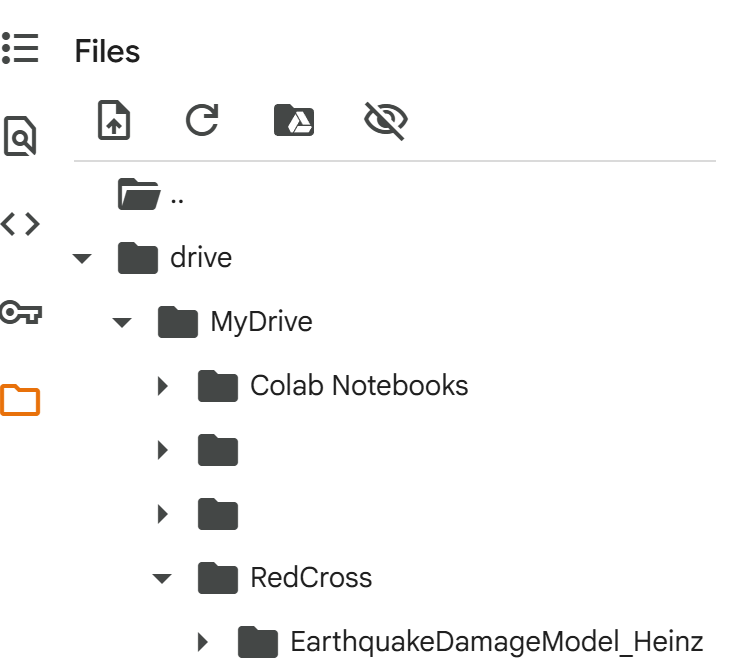

In [ ]:
import os
FILE_PATH = '/content/drive/MyDrive/RedCross/EarthquakeDamageModel_Heinz'
os.chdir(FILE_PATH)
os.listdir(FILE_PATH)


### Verifying that your path is correctly set

When you run the above code to change working directory, the last command `os.listdir` should list the folder contents which should look similar to this:

```
['EarthquakeShelterDemandModel.ipynb',
 'requirements.txt',
 'main.py',
 'Tables',
 'WorkingScripts',
 'Data']
```


In [ ]:
from main import main
import os
import pandas as pd
import time

## Add "params" code snippet below, overwrite anything you see there

In [ ]:
params = {
#"event_id": "ci3144585",
"event_id": "nc72282711",
"intensity_metric": "min",
"BLDNG_USABILITY": {
"Slight":{"FU":1.00,"PU":0.00,"NU":0.00},
"Moderate":{"FU":0.87,"PU":0.13,"NU":0.00},
"Extensive":{"FU":0.25,"PU":0.50,"NU":0.25},
"Complete":{"FU":0.00,"PU":0.02,"NU":0.98}
},
"UL_SEVERITY": {
"low": {"FU": [0.00,0.05], "PU": [0.05,0.10]},
"medium": {"FU": [0.00,0.10], "PU": [0.30,0.50]},
"high": {"FU": [0.10,0.30], "PU": [0.60,0.80]}
},
"SVI_THRESHOLD": [ 0.000, 0.025, 0.050 ]
}

### Once the code completes running:

- Below, we will run the code! Once the code is complete, you will see a file called "model_output_{event_id}.csv"
- download the output file to your local file system, and upload this to the Mass Care Planning Assumptions Spreadsheet.



In [ ]:
df_final, county_rollup, df_o5, df_o4, df_o3 = main(**params)

Save the tract level model and the county rollup output to the Data directory as .csv files with the event ID in the names.

In [ ]:
df_final['GEOID'] = '="'+df_final['GEOID'] + '"'
county_rollup['countyfips'] = '="'+county_rollup['countyfips'] + '"'
df_final.to_csv("Data/model_output_{}.csv".format(params["event_id"]), index=False)
county_rollup.to_csv("Data/county_output_{}.csv".format(params["event_id"]), index=False)